# Mastodon Sentiment Analysis Pipeline
### Module 7150CEM — MSc Data Science Project  
**Coventry University | April 2026**

## PHASE 1 - Data Cleaning & Preprocessing


In [ ]:
#Setup
import pandas as pd
import numpy as np
import re
import os
from html.parser import HTMLParser
import warnings
warnings.filterwarnings("ignore")

# Creating project folders
for folder in ["processed", "figures", "models", "results"]:
    os.makedirs(folder, exist_ok=True)

# Loading raw data
raw_posts = pd.read_csv("mastodon_posts.csv")
print(f"Raw dataset loaded: {raw_posts.shape[0]:,} posts, {raw_posts.shape[1]} columns")
print(f"Columns: {list(raw_posts.columns)}")
raw_posts.head(3)

Raw dataset loaded: 12,000 posts, 9 columns
Columns: ['id', 'created_at', 'content', 'language', 'reblogs_count', 'favourites_count', 'replies_count', 'tags', 'topic_query']


,id,created_at,content,language,reblogs_count,favourites_count,replies_count,tags,topic_query
0,116042290657534809,2026-02-09T19:20:35.506Z,<p>📰 OpenClaw AI Agent Security Crisis Exposes...,tr,0,0,0,"['ainews', 'ai', 'teknoloji', 'machinelearning...",AI
1,116042290613312137,2026-02-09T19:20:34.818Z,<p>📰 AI Image Generation Sparks Debate Over Us...,tr,0,0,0,"['ainews', 'ai', 'teknoloji', 'machinelearning...",AI
2,116042290612111174,2026-02-09T19:20:34.789Z,<p>📰 OpenClaw: İş Dünyasının Yeni Yapay Zeka G...,tr,0,0,0,"['yapayzeka', 'ai', 'teknoloji', 'machinelearn...",AI


In [ ]:
# HTML Tag Stripper
class TagStripper(HTMLParser):
    """Strips all HTML tags and returns plain text."""
    def __init__(self):
        super().__init__()
        self.pieces = []
    def handle_data(self, data):
        self.pieces.append(data)
    def get_clean_text(self):
        return " ".join(self.pieces)

def strip_html_tags(html_content):
    """Removes all HTML markup from a string."""
    if pd.isna(html_content):
        return ""
    stripper = TagStripper()
    stripper.feed(str(html_content))
    return stripper.get_clean_text()

def remove_urls(text):
    """Removes any URLs from the text."""
    return re.sub(r"https?://\S+|www\.\S+", "", str(text))

def clean_whitespace(text):
    """Collapse multiple spaces and strip edges."""
    return re.sub(r"\s+", " ", str(text)).strip()

# Applying cleaning pipeline
posts = raw_posts.copy()
posts["text_clean"] = (
    posts["content"]
    .apply(strip_html_tags)
    .apply(remove_urls)
    .apply(clean_whitespace)
)

# Showing before/after
print("Before vs After Cleaning")
for i in range(3):
    print(f"\nOriginal [{i}]: {str(posts['content'].iloc[i])[:120]}...")
    print(f"Cleaned  [{i}]: {posts['text_clean'].iloc[i][:120]}...")


Before vs After Cleaning

Original [0]: <p>📰 OpenClaw AI Agent Security Crisis Exposes Enterprise Vulnerabilities</p><p>The rapid adoption of the OpenClaw AI ag...
Cleaned  [0]: 📰 OpenClaw AI Agent Security Crisis Exposes Enterprise Vulnerabilities The rapid adoption of the OpenClaw AI agent frame...

Original [1]: <p>📰 AI Image Generation Sparks Debate Over User Intent and Platform Ethics</p><p>A Reddit user&#39;s demand for an AI-g...
Cleaned  [1]: 📰 AI Image Generation Sparks Debate Over User Intent and Platform Ethics A Reddit user's demand for an AI-generated imag...

Original [2]: <p>📰 OpenClaw: İş Dünyasının Yeni Yapay Zeka Güvenlik İkilemi</p><p>Trend Micro&#39;nun analiz ettiği &#39;OpenClaw&#39;...
Cleaned  [2]: 📰 OpenClaw: İş Dünyasının Yeni Yapay Zeka Güvenlik İkilemi Trend Micro'nun analiz ettiği 'OpenClaw' adlı yapay zeka ajan...


In [ ]:
# Handle Missing Languages
print(f"Missing language values: {posts['language'].isna().sum()} ({posts['language'].isna().mean()*100:.1f}%)")

# Filling missing with 'unknown'
posts["language"] = posts["language"].fillna("unknown")

# Parsing timestamps
posts["posted_at"] = pd.to_datetime(posts["created_at"], utc=True)
posts["post_date"] = posts["posted_at"].dt.date
posts["post_hour"] = posts["posted_at"].dt.hour
posts["post_weekday"] = posts["posted_at"].dt.day_name()

# Computing text metrics
posts["word_count"] = posts["text_clean"].str.split().str.len().fillna(0).astype(int)
posts["char_count"] = posts["text_clean"].str.len().fillna(0).astype(int)

# Counting hashtags from the tags column
posts["hashtag_count"] = posts["tags"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and str(x).strip() not in ["[]", ""] else 0
)

# Total engagement
posts["total_engagement"] = posts["reblogs_count"] + posts["favourites_count"] + posts["replies_count"]

print(f"\n Cleaned Dataset Summary")
print(f"Posts: {len(posts):,}")
print(f"Date range: {posts['post_date'].min()} to {posts['post_date'].max()}")
print(f"Languages: {posts['language'].nunique()}")
print(f"Topics: {posts['topic_query'].nunique()} — {posts['topic_query'].unique().tolist()}")
print(f"Avg word count: {posts['word_count'].mean():.0f}")


Missing language values: 595 (5.0%)

 Cleaned Dataset Summary
Posts: 12,000
Date range: 2026-01-21 to 2026-02-09
Languages: 40
Topics: 6 — ['AI', 'climate', 'tech', 'politics', 'health', 'news']
Avg word count: 44


In [ ]:
# Saving Processed Data
posts.to_csv("processed/mastodon_cleaned.csv", index=False)
print(f"Saved: processed/mastodon_cleaned.csv ({len(posts):,} rows)")

Saved: processed/mastodon_cleaned.csv (12,000 rows)


## PHASE 2 - Exploratory Data Analysis
> Engagement patterns, language spread, posting rhythms, topic comparisons


In [ ]:
# Loading & Setupfor Plotting
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

posts = pd.read_csv("processed/mastodon_cleaned.csv", parse_dates=["posted_at"])
print(f"Loaded: {len(posts):,} posts")

Loaded: 12,000 posts


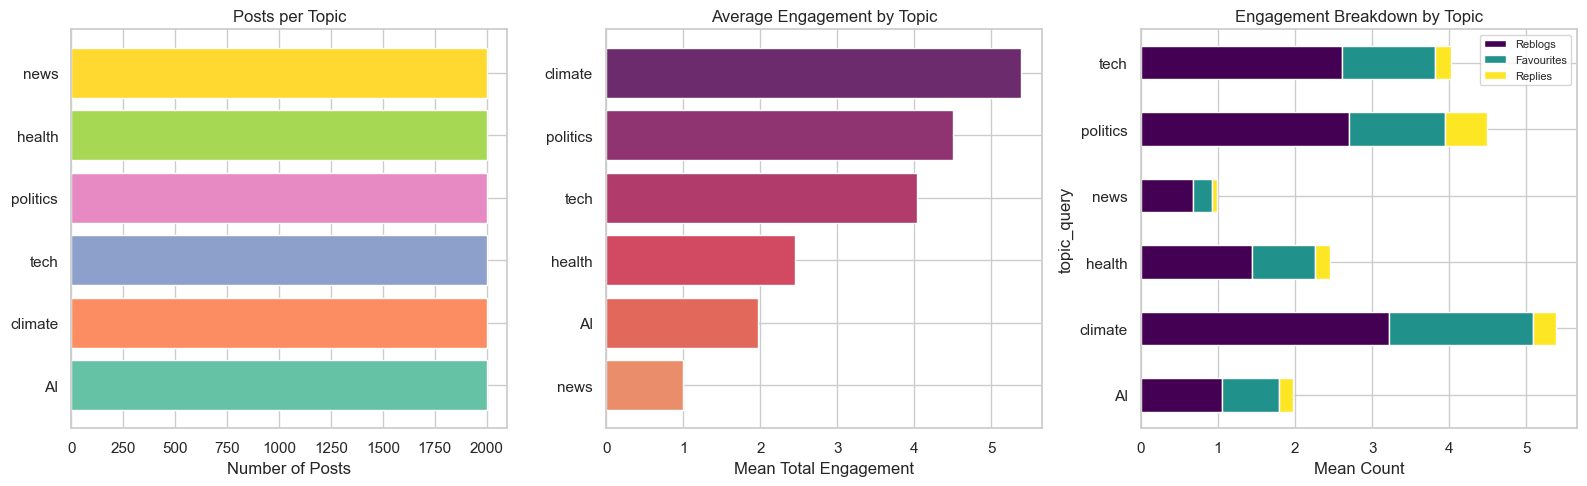

In [ ]:
# Topic Distribution & Engagement
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Posts per topic
topic_counts = posts["topic_query"].value_counts()
axes[0].barh(topic_counts.index, topic_counts.values, color=sns.color_palette("Set2", 6))
axes[0].set_xlabel("Number of Posts")
axes[0].set_title("Posts per Topic")

# Avg engagement per topic
topic_eng = posts.groupby("topic_query")["total_engagement"].mean().sort_values()
axes[1].barh(topic_eng.index, topic_eng.values, color=sns.color_palette("flare", 6))
axes[1].set_xlabel("Mean Total Engagement")
axes[1].set_title("Average Engagement by Topic")

# Engagement type breakdown
eng_by_topic = posts.groupby("topic_query")[["reblogs_count", "favourites_count", "replies_count"]].mean()
eng_by_topic.plot(kind="barh", stacked=True, ax=axes[2], colormap="viridis")
axes[2].set_xlabel("Mean Count")
axes[2].set_title("Engagement Breakdown by Topic")
axes[2].legend(["Reblogs", "Favourites", "Replies"], fontsize=8)

plt.tight_layout()
plt.savefig("figures/01_topic_overview.png", dpi=150, bbox_inches="tight")
plt.show()


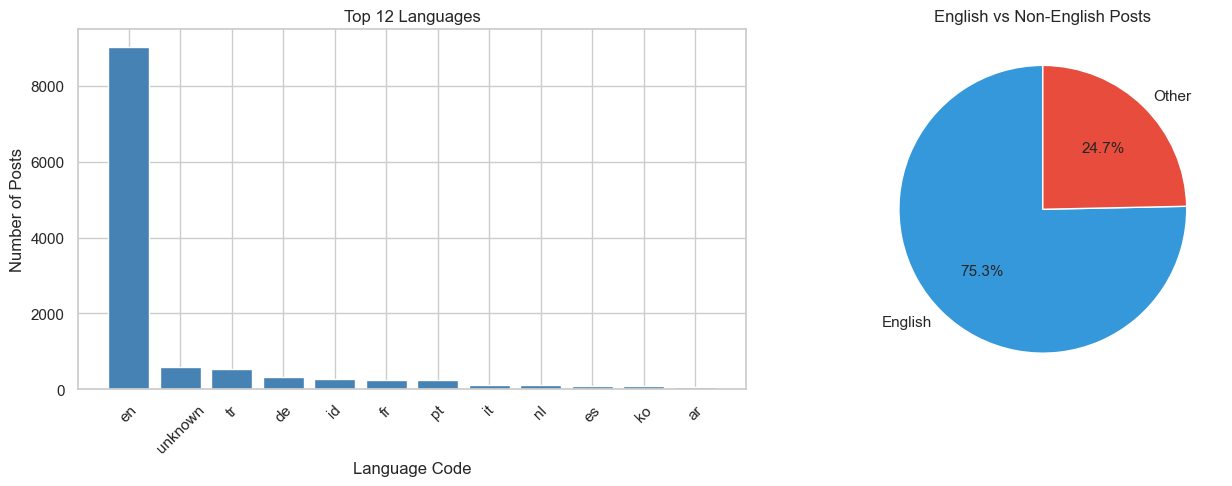

English: 9,040 (75.3%) | Other: 2,960


In [ ]:
# Language Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 12 languages
lang_counts = posts["language"].value_counts().head(12)
axes[0].bar(lang_counts.index, lang_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Language Code")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title("Top 12 Languages")
axes[0].tick_params(axis="x", rotation=45)

# English vs non-English
is_english = (posts["language"] == "en").sum()
not_english = len(posts) - is_english
axes[1].pie([is_english, not_english], labels=["English", "Other"],
            autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
axes[1].set_title("English vs Non-English Posts")

plt.tight_layout()
plt.savefig("figures/02_language_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"English: {is_english:,} ({is_english/len(posts)*100:.1f}%) | Other: {not_english:,}")


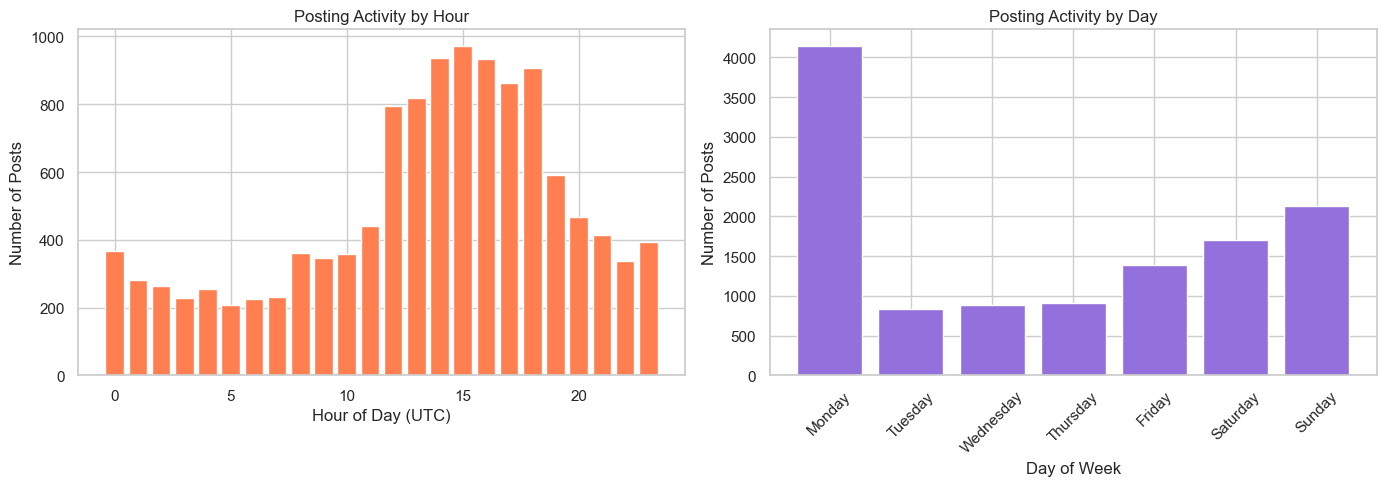

In [ ]:
# Posting Time Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly distribution
hourly = posts.groupby("post_hour").size()
axes[0].bar(hourly.index, hourly.values, color="coral", edgecolor="white")
axes[0].set_xlabel("Hour of Day (UTC)")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title("Posting Activity by Hour")

# Day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = posts["post_weekday"].value_counts().reindex(dow_order)
axes[1].bar(dow_order, dow_counts.values, color="mediumpurple", edgecolor="white")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Posts")
axes[1].set_title("Posting Activity by Day")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/03_posting_patterns.png", dpi=150, bbox_inches="tight")
plt.show()


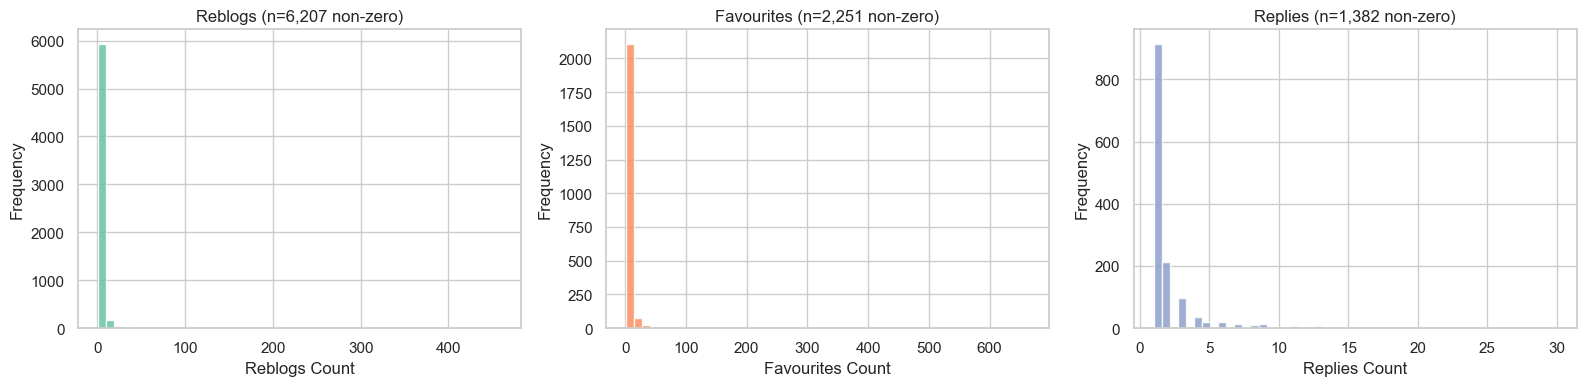

Engagement Summary
  reblogs_count: mean=1.95, median=1, non-zero=6,207 (51.7%)
  favourites_count: mean=1.02, median=0, non-zero=2,251 (18.8%)
  replies_count: mean=0.25, median=0, non-zero=1,382 (11.5%)
  total_engagement: mean=3.22, median=1, non-zero=6,687 (55.7%)


In [ ]:
# Engagement Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(["reblogs_count", "favourites_count", "replies_count"]):
    data = posts[posts[col] > 0][col]
    axes[i].hist(data, bins=50, color=sns.color_palette("Set2")[i], edgecolor="white", alpha=0.85)
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"{col.replace('_count','').title()} (n={len(data):,} non-zero)")

plt.tight_layout()
plt.savefig("figures/04_engagement_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Engagement Summary")
for col in ["reblogs_count", "favourites_count", "replies_count", "total_engagement"]:
    nz = (posts[col] > 0).sum()
    print(f"  {col}: mean={posts[col].mean():.2f}, median={posts[col].median():.0f}, non-zero={nz:,} ({nz/len(posts)*100:.1f}%)")


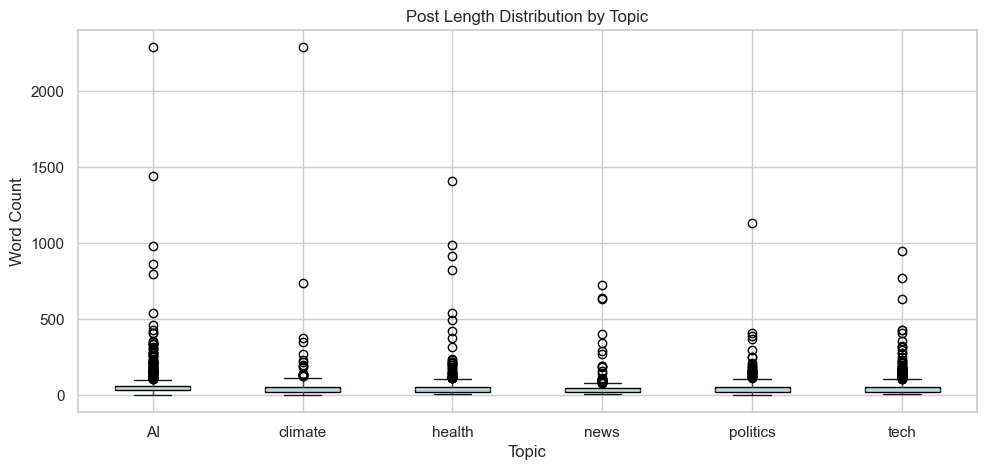

In [ ]:
# Word Count by Topic
fig, ax = plt.subplots(figsize=(10, 5))
posts.boxplot(column="word_count", by="topic_query", ax=ax, patch_artist=True,
              boxprops=dict(facecolor="lightblue"))
ax.set_xlabel("Topic")
ax.set_ylabel("Word Count")
ax.set_title("Post Length Distribution by Topic")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/05_wordcount_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()


## PHASE 3 - Sentiment Classification
> VADER baseline > DistilBERT fine-tuning > compare both > assign final labels


In [ ]:
# VADER Sentiment Baseline
# !pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

posts = pd.read_csv("processed/mastodon_cleaned.csv", parse_dates=["posted_at"])

analyser = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    """Returns compound, positive, negative, neutral scores from VADER."""
    scores = analyser.polarity_scores(str(text))
    return scores["compound"], scores["pos"], scores["neg"], scores["neu"]

# Applying VADER to all posts
vader_results = posts["text_clean"].apply(lambda t: pd.Series(get_vader_scores(t)))
vader_results.columns = ["vader_compound", "vader_pos", "vader_neg", "vader_neu"]
posts = pd.concat([posts, vader_results], axis=1)

# Classifying based on compound score thresholds
def vader_label(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

posts["vader_sentiment"] = posts["vader_compound"].apply(vader_label)

print("VADER Sentiment Results")
print(posts["vader_sentiment"].value_counts())
print(f"\nCompound score stats:")
print(posts["vader_compound"].describe())


VADER Sentiment Results
vader_sentiment
positive    4335
neutral     3980
negative    3685
Name: count, dtype: int64

Compound score stats:
count    12000.000000
mean         0.028822
std          0.483670
min         -0.999000
25%         -0.296000
50%          0.000000
75%          0.381800
max          0.999700
Name: vader_compound, dtype: float64


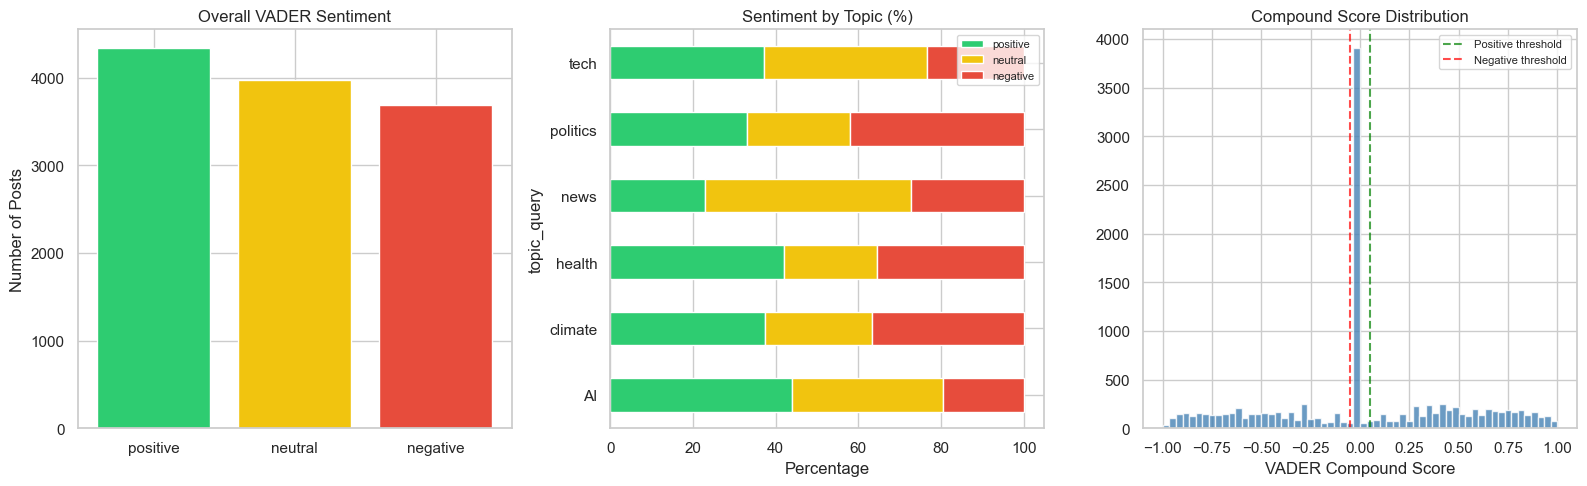

In [ ]:
# Visualise VADER Results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall sentiment split
sent_counts = posts["vader_sentiment"].value_counts()
colours_sent = {"positive": "#2ecc71", "neutral": "#f1c40f", "negative": "#e74c3c"}
axes[0].bar(sent_counts.index, sent_counts.values, color=[colours_sent[s] for s in sent_counts.index])
axes[0].set_title("Overall VADER Sentiment")
axes[0].set_ylabel("Number of Posts")

# Sentiment by topic
topic_sent = pd.crosstab(posts["topic_query"], posts["vader_sentiment"], normalize="index") * 100
topic_sent[["positive", "neutral", "negative"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#2ecc71", "#f1c40f", "#e74c3c"]
)
axes[1].set_xlabel("Percentage")
axes[1].set_title("Sentiment by Topic (%)")
axes[1].legend(fontsize=8)

# Compound score distribution
axes[2].hist(posts["vader_compound"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[2].axvline(0.05, color="green", linestyle="--", alpha=0.7, label="Positive threshold")
axes[2].axvline(-0.05, color="red", linestyle="--", alpha=0.7, label="Negative threshold")
axes[2].set_xlabel("VADER Compound Score")
axes[2].set_title("Compound Score Distribution")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/06_vader_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# DistilBERT Sentiment Classification
# !pip install transformers torch
from transformers import pipeline

# Loading pre-trained sentiment pipeline (no fine-tuning needed for this model)
# distilbert-base-uncased-finetuned-sst-2-english is already trained on sentiment
print("Loading DistilBERT sentiment model...")
bert_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Applying in batches (faster than row by row)
batch_size = 64
bert_labels = []
bert_scores = []

texts = posts["text_clean"].tolist()
for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    # Handling empty strings
    batch = [t if len(str(t).strip()) > 0 else "neutral" for t in batch]
    results = bert_sentiment(batch)
    for r in results:
        bert_labels.append(r["label"].lower())
        bert_scores.append(r["score"])
    if (i // batch_size) % 20 == 0:
        print(f"  Processed {min(i+batch_size, len(texts)):,}/{len(texts):,} posts...")

posts["bert_sentiment"] = bert_labels
posts["bert_confidence"] = bert_scores

print(f"\nDistilBERT Results")
print(posts["bert_sentiment"].value_counts())
print(f"Mean confidence: {posts['bert_confidence'].mean():.3f}")


Loading DistilBERT sentiment model...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6218.92it/s]


  Processed 64/12,000 posts...


In [ ]:
# Comparing VADER vs DistilBERT
# Mapping BERT labels to match VADER style
posts["bert_sentiment_mapped"] = posts["bert_sentiment"].map(
    {"positive": "positive", "negative": "negative"}
).fillna("neutral")

# Agreement rate
agreement = (posts["vader_sentiment"] == posts["bert_sentiment_mapped"]).mean()
print(f"VADER vs DistilBERT agreement: {agreement*100:.1f}%")

# Cross-tabulation
print("\nCross-tabulation (rows=VADER, cols=BERT):")
print(pd.crosstab(posts["vader_sentiment"], posts["bert_sentiment_mapped"], margins=True))

# Use VADER as primary (it handles multilingual and neutral better for social media)
posts["final_sentiment"] = posts["vader_sentiment"]
print(f"\nFinal sentiment labels assigned using VADER.")

# Save with sentiment
posts.to_csv("processed/mastodon_with_sentiment.csv", index=False)
print(f"Saved: processed/mastodon_with_sentiment.csv")


NameError: name 'posts' is not defined

# PHASE 4 - Topic Modelling 
> BERTopic for automatic theme discovery, topic-sentiment relationships


In [ ]:
# BERTopic Topic Modelling
# !pip install bertopic
from bertopic import BERTopic

posts = pd.read_csv("processed/mastodon_with_sentiment.csv")

# Filtering to English posts with enough text for meaningful topics
english_posts = posts[(posts["language"] == "en") & (posts["word_count"] > 10)].copy()
print(f"English posts with 10+ words: {len(english_posts):,}")

# Fitting BERTopic
print("Fitting BERTopic model (this may take a few minutes)...")
topic_model = BERTopic(
    nr_topics="auto",
    min_topic_size=30,
    verbose=True
)
topics, probs = topic_model.fit_transform(english_posts["text_clean"].tolist())

english_posts["bertopic_id"] = topics
english_posts["bertopic_prob"] = probs

# Summary
topic_info = topic_model.get_topic_info()
print(f"\n BERTopic Results")
print(f"Topics discovered: {len(topic_info) - 1} (excluding outlier topic -1)")
print(f"\nTop 10 topics:")
print(topic_info.head(11).to_string())


ModuleNotFoundError: No module named 'bertopic'

In [ ]:
# Visualise Topics
# Topic frequency bar chart

import kaleido

fig = topic_model.visualize_barchart(top_n_topics=10)
fig.write_html("figures/07_bertopic_barchart.html")
fig.show()

# Topic-sentiment cross-analysis
topic_sent = pd.crosstab(
    english_posts["bertopic_id"],
    english_posts["final_sentiment"],
    normalize="index"
) * 100

# Shows top 8 topics sentiment breakdown
top_topics = english_posts["bertopic_id"].value_counts().head(8).index.tolist()
if -1 in top_topics:
    top_topics.remove(-1)
    top_topics = top_topics[:8]

fig, ax = plt.subplots(figsize=(10, 6))
topic_sent.loc[top_topics][["positive", "neutral", "negative"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2ecc71", "#f1c40f", "#e74c3c"]
)
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Topic ID")
ax.set_title("Sentiment Distribution Across Top BERTopic Topics")
ax.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("figures/08_topic_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

# Saving topic model
topic_model.save("models/bertopic_model")
print("BERTopic model saved to models/bertopic_model")


ModuleNotFoundError: No module named 'kaleido'

## PHASE 5 - Engagement Prediction
> XGBoost model to predict post engagement from content and metadata features


In [ ]:
# Preparing Features for Engagement Prediction
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import joblib

posts = pd.read_csv("processed/mastodon_with_sentiment.csv")

# Feature engineering
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
posts["sentiment_numeric"] = posts["final_sentiment"].map(sentiment_map).fillna(0)

# One-hot encode topic
topic_dummies = pd.get_dummies(posts["topic_query"], prefix="topic")

# Language flag
posts["is_english"] = (posts["language"] == "en").astype(int)

# Assemble feature matrix
feature_cols = ["word_count", "char_count", "hashtag_count", "post_hour",
                "sentiment_numeric", "vader_compound", "is_english"]

X = pd.concat([posts[feature_cols], topic_dummies], axis=1)
y = posts["total_engagement"]

print(f"Feature matrix: {X.shape}")
print(f"Target (total engagement): mean={y.mean():.2f}, median={y.median():.0f}, max={y.max()}")


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# Train XGBoost Regressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

engagement_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

engagement_model.fit(X_train, y_train)
preds = engagement_model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("Engagement Prediction Results")
print(f"  RMSE: {rmse:.3f}")
print(f"  MAE:  {mae:.3f}")
print(f"  R^2:   {r2:.4f}")

joblib.dump(engagement_model, "models/engagement_xgboost.pkl")
print("Model saved: models/engagement_xgboost.pkl")


Engagement Prediction Results
  RMSE: 14.436
  MAE:  3.892
  R^2:   -0.1041
Model saved: models/engagement_xgboost.pkl


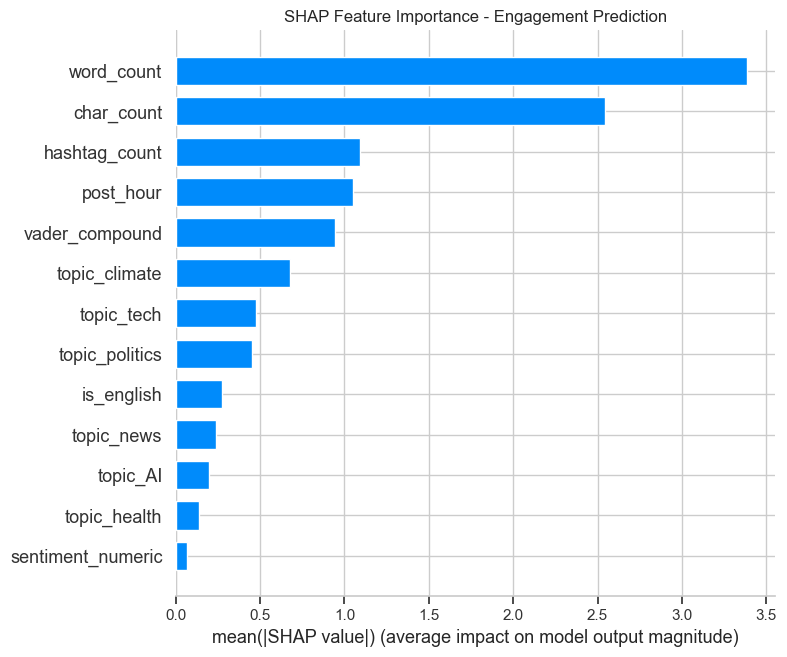

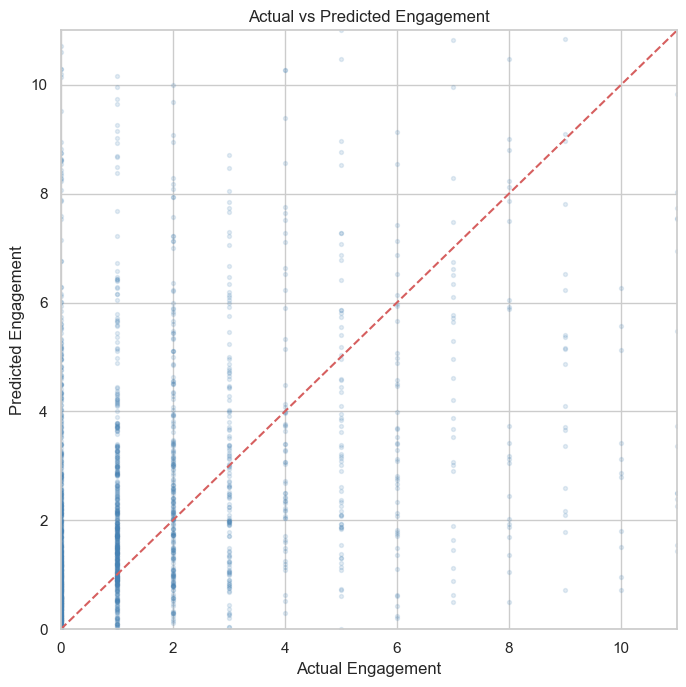

In [ ]:
# SHAP Feature Importance
explainer = shap.TreeExplainer(engagement_model)
shap_vals = explainer.shap_values(X_test.sample(n=min(500, len(X_test)), random_state=42))
sample_X = X_test.sample(n=min(500, len(X_test)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals, sample_X, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance - Engagement Prediction")
plt.tight_layout()
plt.savefig("figures/09_shap_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

# Actual vs predicted
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, preds, alpha=0.15, s=8, color="steelblue")
lim = np.percentile(y_test, 95)
ax.plot([0, lim], [0, lim], "r--", linewidth=1.5)
ax.set_xlabel("Actual Engagement")
ax.set_ylabel("Predicted Engagement")
ax.set_title("Actual vs Predicted Engagement")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.savefig("figures/10_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


## PHASE 6 - Time-Series & Final Outputs
> Sentiment trends over time, export results for report, dashboard code in separate file


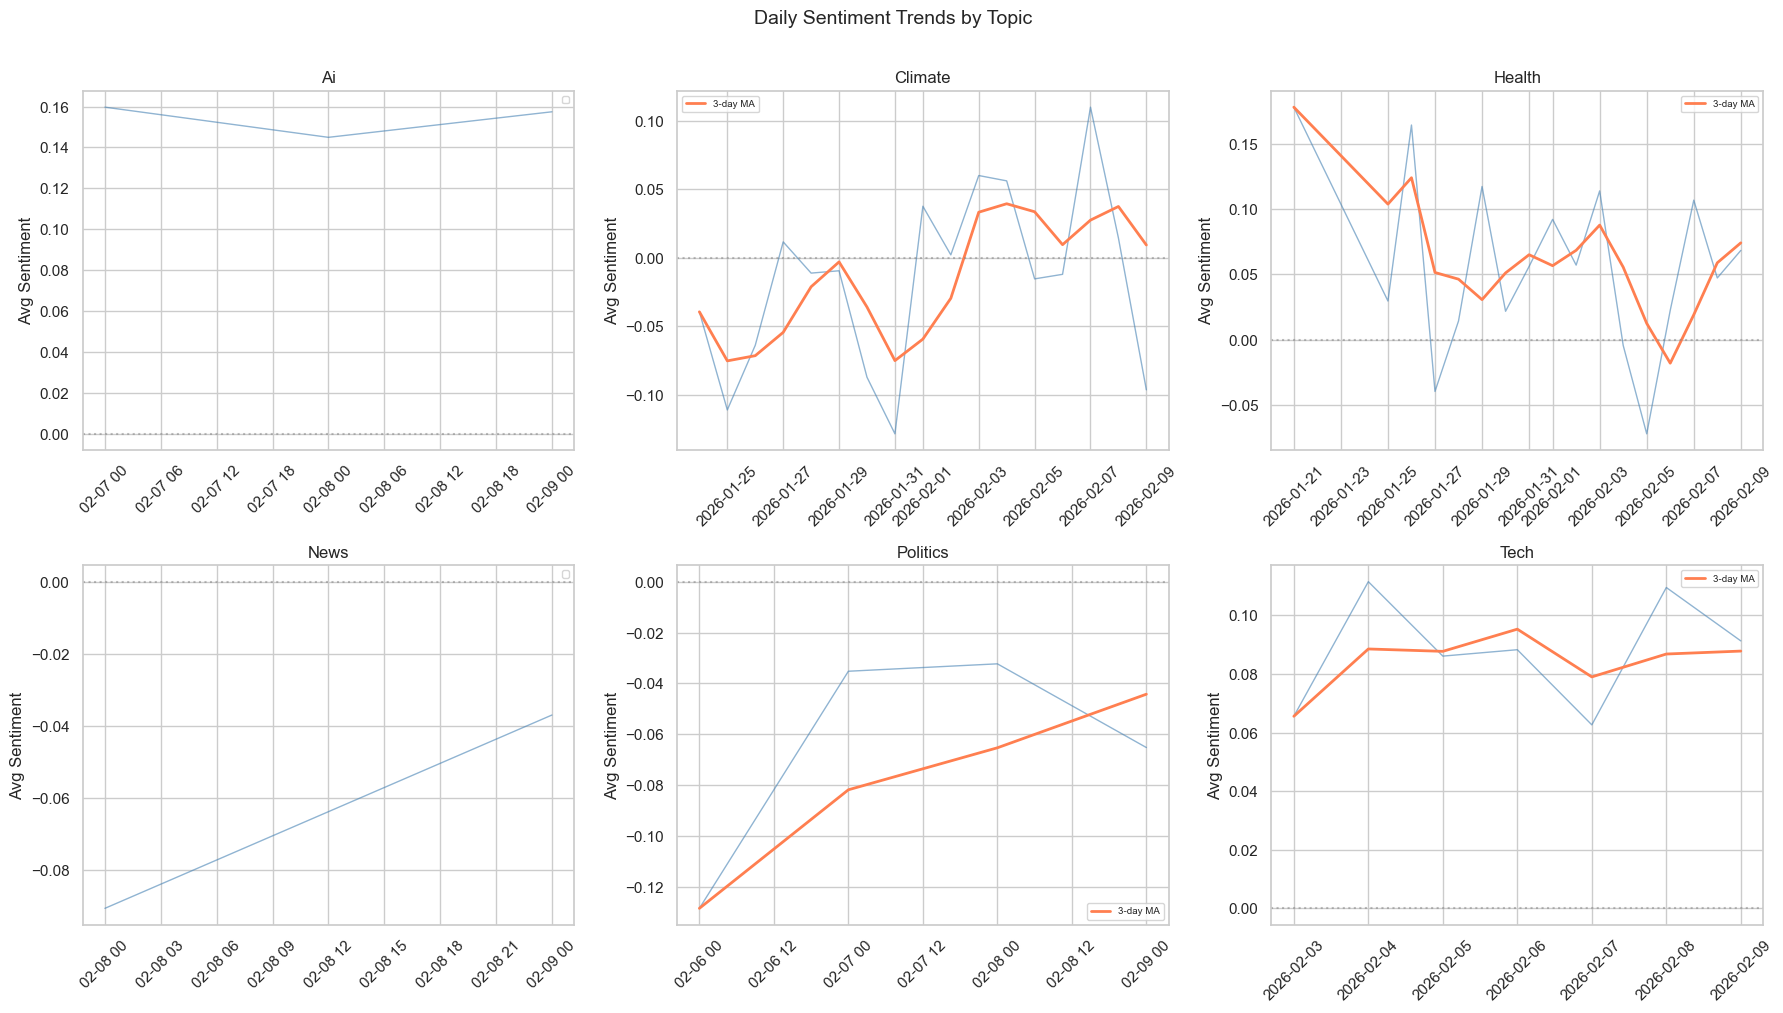

In [ ]:
# Sentiment Trends Over Time
posts["posted_at"] = pd.to_datetime(posts["posted_at"], format="ISO8601")
posts["post_date"] = posts["posted_at"].dt.date

# Daily sentiment averages per topic
daily_sentiment = posts.groupby(["post_date", "topic_query"]).agg(
    avg_compound=("vader_compound", "mean"),
    post_count=("id", "size")
).reset_index()
daily_sentiment["post_date"] = pd.to_datetime(daily_sentiment["post_date"])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
topics = posts["topic_query"].unique()
for i, topic in enumerate(sorted(topics)):
    ax = axes[i // 3, i % 3]
    topic_data = daily_sentiment[daily_sentiment["topic_query"] == topic].sort_values("post_date")
    ax.plot(topic_data["post_date"], topic_data["avg_compound"], linewidth=1, alpha=0.6, color="steelblue")
    # Rolling average
    if len(topic_data) > 3:
        rolling = topic_data["avg_compound"].rolling(3, min_periods=1).mean()
        ax.plot(topic_data["post_date"], rolling, linewidth=2, color="coral", label="3-day MA")
    ax.axhline(0, color="grey", linestyle=":", alpha=0.5)
    ax.set_title(f"{topic.title()}")
    ax.set_ylabel("Avg Sentiment")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=7)

plt.suptitle("Daily Sentiment Trends by Topic", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/11_sentiment_trends.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Exporting Results Summary
import json

results_summary = {
    "dataset": {
        "total_posts": len(posts),
        "languages": int(posts["language"].nunique()),
        "topics": posts["topic_query"].unique().tolist(),
        "date_range": f"{posts['post_date'].min()} to {posts['post_date'].max()}"
    },
    "sentiment_distribution": posts["final_sentiment"].value_counts().to_dict(),
    "engagement_model": {
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "R2": round(r2, 4)
    }
}

with open("results/results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2, default=str)

print("Final Results")
print(json.dumps(results_summary, indent=2, default=str))

print(f"\nFigures saved: {len(os.listdir('figures'))}")
print(f"Models saved: {len(os.listdir('models'))}")


Final Results
{
  "dataset": {
    "total_posts": 12000,
    "languages": 40,
    "topics": [
      "AI",
      "climate",
      "tech",
      "politics",
      "health",
      "news"
    ],
    "date_range": "2026-01-21 to 2026-02-09"
  },
  "sentiment_distribution": {
    "positive": 4335,
    "neutral": 3980,
    "negative": 3685
  },
  "engagement_model": {
    "RMSE": 14.436,
    "MAE": 3.892,
    "R2": -0.1041
  }
}

Figures saved: 11
Models saved: 2
